In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [101]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

energies = np.linspace(-3,3,1000) 
dos_interface, dos_bulk = H.dos_local(energies, eta=0.0051,interface_width=20)

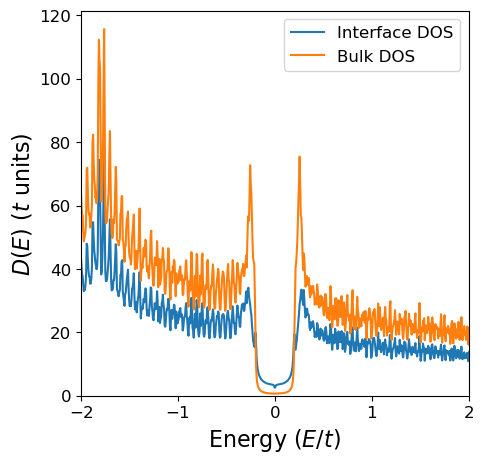

In [102]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_interface / H.lattice.Y, label='Interface DOS')
plt.plot(energies, dos_bulk / H.lattice.Y, label='Bulk DOS')
plt.ylim(0, None)
plt.xlim(-2, 2)
plt.xticks([-2, -1, 0, 1, 2])
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [103]:
X, Y = 100,100
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1 * t
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1, -0.1])

energies = np.linspace(-3,3,3000) 
dos_interface, dos_bulk = H.dos_local(energies, eta=0.00751,interface_width=20)

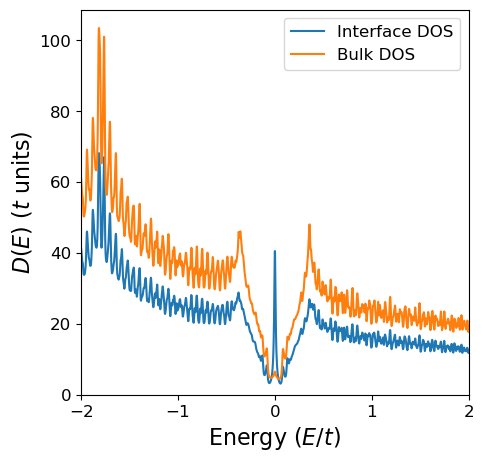

In [105]:
plt.figure(figsize=(5,5))
plt.plot(energies, dos_interface / H.lattice.Y, label='Interface DOS')
plt.plot(energies, dos_bulk / H.lattice.Y, label='Bulk DOS')
plt.ylim(0, None)
plt.xlim(-2, 2)
plt.xticks([-2, -1, 0, 1, 2])
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.show()